# **Analiza szeregów czasowych warunków meteorologicznych w otoczeniu obiektów wydobycia gazu w Polsce, 2019–2026**

Kacper Andrzejewski 2026

---

### Poniższy raport stanowi procedurę przeprowadzenia analizy szeregu czasowego warunków meteorologicznych na podstawie zbioru `wszystkie_miasta_CH4.csv`. Z pełnego zbioru danych wybrano wyłącznie cztery zmienne meteorologiczne:

- **temperature_2m_mean** — średnia dobowa temperatura powietrza na wysokości 2 m nad gruntem (K),
- **dewpoint_temperature_2m_mean** — średnia dobowa temperatura punktu rosy na 2 m, będąca miarą zawartości pary wodnej w powietrzu (K),
- **surface_pressure_mean** — średnie dobowe ciśnienie atmosferyczne na poziomie gruntu (Pa),
- **predkosc_wiatru_mean** — średnia dobowa prędkość wiatru (m/s).

Pozostałe kolumny zbioru (stężenia gazów śladowych, odległość od źródła, współrzędne pikseli, wilgotność względna, wartości min/max) świadomie **pominięto** — nie należą one do zakresu tej części opracowania, którą stanowi wyłącznie preprocessing oraz analiza szeregu czasowego samych danych pogodowych. Wilgotność względną pominięto dodatkowo dlatego, że jest ona funkcją temperatury i punktu rosy, więc nie wnosi informacji niezależnej.

### Celem analizy jest odpowiedź na następujące pytania:

1. Czy warunki meteorologiczne w badanym obszarze wykazują trend w badanym okresie?
2. Jaka jest sezonowość poszczególnych zmiennych i czy jej charakter (amplituda, przebieg) zmienia się między kolejnymi latami?
3. Jak często i w których latach występują wartości ekstremalne poszczególnych zmiennych?
4. Jakie zależności fizyczne łączą temperaturę, punkt rosy, ciśnienie i wiatr?

### Istotne ograniczenie zbioru, determinujące metodykę pracy: dane obejmują wyłącznie **dwa trzymiesięczne okna w każdym roku** — miesiące I–III (zima) oraz VI–VIII (lato). Miesiące przejściowe (IV–V, IX–XII) nie są reprezentowane. Jest to założenie projektowe (celowy dobór skrajnych pór roku), ale wyklucza zastosowanie klasycznej dekompozycji szeregu czasowego o okresie 12 miesięcy, ponieważ połowa okresu nie istnieje w danych. Z tego względu przyjęto podejście oparte na **dwóch równoległych podszeregach — zimowym i letnim — analizowanych osobno**, co zostanie szczegółowo omówione w Części II.


---
# Część I — preprocessing danych

### Pierwszym etapem jest wczytanie danych oraz rozpoznanie ich struktury. Zbiór jest stosunkowo duży, dlatego już na etapie wczytywania ograniczono się do kolumn wykorzystywanych w analizie.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 9,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

KOL = {'T': '#e67e22', 'TD': '#16a085', 'P': '#2980b9', 'W': '#8e44ad'}
KOL_SEZ = {'ZIMA': '#2980b9', 'LATO': '#c0392b'}
OPISY = {'T': 'Temperatura [°C]', 'TD': 'Punkt rosy [°C]',
         'P': 'Cisnienie [hPa]', 'W': 'Predkosc wiatru [m/s]'}

In [ ]:

from google.colab import drive; drive.mount('/content/drive')
SCIEZKA = '/content/drive/MyDrive/DataTeam_Orlen/wszystkie_miasta_CH4.csv'

# SCIEZKA = 'wszystkie_miasta_CH4.csv'

KOLUMNY = ['Data', 'Rok', 'Miesiac', 'Sezon', 'folder',
           'temperature_2m_mean', 'dewpoint_temperature_2m_mean',
           'surface_pressure_mean', 'predkosc_wiatru_mean']

df = pd.read_csv(SCIEZKA, usecols=KOLUMNY,
                 dtype={'Data': str, 'Sezon': str, 'folder': str})

df = df.rename(columns={
    'temperature_2m_mean': 'T',
    'dewpoint_temperature_2m_mean': 'TD',
    'surface_pressure_mean': 'P',
    'predkosc_wiatru_mean': 'W',
})

print(f'Wymiary zbioru: {df.shape[0]} wierszy x {df.shape[1]} kolumn')

df.head(10)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Wymiary zbioru: 192146 wierszy x 9 kolumn


,Data,Rok,Miesiac,Sezon,T,TD,W,P,folder
0,2019-02-05,2019,2,ZIMA,270.054485,268.556677,2.948308,101350.538411,bogdaj_uciechow
1,2019-02-05,2019,2,ZIMA,270.054485,268.556677,2.948308,101350.538411,bogdaj_uciechow
2,2019-02-05,2019,2,ZIMA,270.054485,268.556677,2.948308,101350.538411,bogdaj_uciechow
3,2019-02-05,2019,2,ZIMA,270.054485,268.556677,2.948308,101350.538411,bogdaj_uciechow
4,2019-02-05,2019,2,ZIMA,270.054485,268.556677,2.948308,101350.538411,bogdaj_uciechow
5,2019-02-05,2019,2,ZIMA,270.054485,268.556677,2.948308,101350.538411,bogdaj_uciechow
6,2019-02-05,2019,2,ZIMA,270.054485,268.556677,2.948308,101350.538411,bogdaj_uciechow
7,2019-02-05,2019,2,ZIMA,270.054485,268.556677,2.948308,101350.538411,bogdaj_uciechow
8,2019-02-05,2019,2,ZIMA,270.054485,268.556677,2.948308,101350.538411,bogdaj_uciechow
9,2019-02-05,2019,2,ZIMA,270.054485,268.556677,2.948308,101350.538411,bogdaj_uciechow


Tabela 1. — pierwsze 10 wierszy wybranego podzbioru danych

Widoczna jest istotna cecha struktury zbioru: dla tej samej daty i lokalizacji występuje wiele wierszy — jest to konsekwencja tego, że oryginalny zbiór jest zorganizowany na poziomie pojedynczego piksela satelitarnego pomiaru metanu, a dane pogodowe (dobowe, jednakowe dla całego obszaru wokół danej lokalizacji) zostały po prostu powielone na każdy z tych pikseli. Ma to bezpośrednią konsekwencję dla dalszego postępowania.

##### Kolejnym krokiem jest sprawdzenie liczby brakujących wartości oraz typów danych.

In [ ]:
podsumowanie = pd.DataFrame({
    'Braki (NaN)': df.isna().sum(),
    'Udzial brakow [%]': (df.isna().mean() * 100).round(2),
    'Typ danych': df.dtypes.astype(str),
})
podsumowanie

,Braki (NaN),Udzial brakow [%],Typ danych
Data,0,0.00,object
Rok,0,0.00,int64
Miesiac,0,0.00,int64
Sezon,0,0.00,object
T,9116,4.74,float64
TD,9116,4.74,float64
W,9116,4.74,float64
P,9116,4.74,float64
folder,0,0.00,object


Tabela 2. — liczba brakujących wartości i typy danych

Braki występują wyłącznie w czterech kolumnach meteorologicznych, i to w identycznej liczbie **9116 wierszy** w każdej z nich. Nie jest to zjawisko losowe — identyczna liczba braków w czterech różnych kolumnach sugeruje, że są one skoncentrowane w obrębie jednej jednostki obserwacji, a nie rozproszone po całym zbiorze. Należy to zweryfikować przed podjęciem decyzji o sposobie ich obsługi, ponieważ mechanizm powstania braków determinuje poprawną strategię: braki losowe można uzupełnić lub usunąć wierszami, natomiast braki systematyczne wymagają decyzji na poziomie całej jednostki obserwacji.

In [ ]:
braki_lok = (df.groupby('folder')['T']
               .apply(lambda s: s.isna().mean() * 100)
               .round(1)
               .sort_values(ascending=False))
print('Udzial brakow danych meteorologicznych w kazdej lokalizacji [%]:')
print(braki_lok.head(5).to_string())

Udzial brakow danych meteorologicznych w kazdej lokalizacji [%]:
folder
zalecze              100.0
Lancut_Jodlowka        0.0
Tarnow_Szczepanow      0.0
Tarnow_Tarnow2         0.0
Krosno_Roztoki         0.0


Hipoteza została potwierdzona. Braki nie są rozproszone — **cała lokalizacja `zalecze` nie posiada danych meteorologicznych (100% braków)**, natomiast wszystkie pozostałe lokalizacje mają dane kompletne (0% braków). Oznacza to, że dla tego jednego punktu reanaliza meteorologiczna nie została dołączona do zbioru.

W tej sytuacji uzupełnianie braków (imputacja) byłoby błędem metodycznym — nie istnieje żadna informacja o pogodzie w tym punkcie, którą można byłoby wykorzystać, a imputacja średnią z innych lokalizacji oznaczałaby przypisanie temu punktowi pogody z miejsc odległych o kilkaset kilometrów. Ponieważ analiza opiera się właśnie na wartościach meteorologicznych, **lokalizacja ta zostaje usunięta ze zbioru w całości**. Pozostaje 20 lokalizacji z kompletnymi danymi.

In [ ]:
df_lok = df[df.folder != 'zalecze'].copy()
print(f'Po usunieciu: {df_lok.shape[0]} wierszy, {df_lok.folder.nunique()} lokalizacji')
print(f'Pozostale braki danych: {df_lok.isna().sum().sum()}')

Po usunieciu: 183030 wierszy, 20 lokalizacji
Pozostale braki danych: 0


##### Następnym etapem jest redukcja duplikatów wynikających z wielokrotnego powielenia wartości pogodowej na piksele satelitarne. Przed uśrednieniem warto zweryfikować, czy w obrębie pary (lokalizacja, dzień) wartość pogodowa jest rzeczywiście stała — jeżeli tak, agregacja średnią nie zmieni żadnej wartości, a jedynie usunie sztuczne powielenia.

In [ ]:
sprawdzenie = df_lok.groupby(['folder', 'Data'])['T'].nunique()
print('Liczba unikalnych wartosci temperatury w obrebie pary (lokalizacja, dzien):')
print(sprawdzenie.value_counts().to_string())
print(f'\nSrednia liczba powielonych wierszy na lokalizacje i dzien: '
      f'{df_lok.groupby(["folder","Data"]).size().mean():.1f}')

Liczba unikalnych wartosci temperatury w obrebie pary (lokalizacja, dzien):
T
1    4687

Srednia liczba powielonych wierszy na lokalizacje i dzien: 39.1


Weryfikacja wypadła jednoznacznie: w obrębie każdej pary (lokalizacja, dzień) istnieje dokładnie **jedna** unikalna wartość temperatury. Redukcja jest zatem bezpieczna — nie usuwa żadnej informacji, a jedynie eliminuje sztuczne powielenie wynikające ze struktury oryginalnego pliku (który powstał z myślą o zmiennej CH4, mierzonej faktycznie na poziomie pojedynczego piksela).

Warto dodać, że pozostawienie danych w postaci niezredukowanej byłoby błędem nawet dla samej pogody: liczba dostępnych pikseli w danym dniu zależy od zachmurzenia (przy dużym zachmurzeniu satelitarny odczyt CH4 zawodzi dla większości pikseli), a zachmurzenie koreluje z samą pogodą. Nieredukowany zbiór nadawałby zatem dniom pogodnym (więcej pikseli = więcej powielonych wierszy) większą wagę w każdej dalszej średniej, wprowadzając ukryte obciążenie.

Przy okazji redukcji wykonana zostanie konwersja jednostek do wartości standardowo stosowanych w meteorologii:

- ***T*** oraz ***TD*** — K --> °C (odjęcie 273,15),
- ***P*** — Pa --> hPa (podzielenie przez 100),
- ***W*** — m/s (bez zmian, jednostka już standardowa).

In [ ]:
ZM = ['T', 'TD', 'P', 'W']

dane = (df_lok.groupby(['folder', 'Data'], as_index=False)[ZM].mean())

dane['T'] = dane['T'] - 273.15
dane['TD'] = dane['TD'] - 273.15
dane['P'] = dane['P'] / 100.0

dane['Data'] = pd.to_datetime(dane['Data'])
dane['Rok'] = dane['Data'].dt.year
dane['Mies'] = dane['Data'].dt.month
dane['Sezon'] = np.where(dane['Mies'] <= 3, 'ZIMA', 'LATO')
dane = dane.sort_values('Data').reset_index(drop=True)

print(f'Po redukcji: {len(dane)} obserwacji dobowych '
      f'({dane.Data.nunique()} unikalnych dni, {dane.folder.nunique()} lokalizacji)')
dane[ZM].describe().round(2)

Po redukcji: 4687 obserwacji dobowych (552 unikalnych dni, 20 lokalizacji)


,T,TD,P,W
count,4687.00,4687.00,4687.00,4687.00
mean,13.31,6.42,997.84,2.65
std,10.21,8.89,12.82,0.91
min,-13.97,-18.40,954.08,0.70
25%,3.92,-0.87,987.63,1.99
50%,17.53,8.38,995.69,2.56
75%,22.57,14.38,1007.86,3.19
max,31.98,21.67,1037.43,7.20


Tabela 3. — podstawowe statystyki zmiennych po redukcji duplikatów i konwersji jednostek

Redukcja z ponad 183 tys. wierszy do 4687 obserwacji dobowych jest zgodna z oczekiwaniem — zbiór zawiera 552 unikalne dni, a każda z 20 lokalizacji wnosi od 200 do 279 dni obserwacji.

Statystyki potwierdzają **fizyczną wiarygodność** wszystkich zmiennych:

- temperatura mieści się w przedziale od −13,97 °C do 31,98 °C — zakres realistyczny dla polskich zim i lat,
- punkt rosy (od −18,40 °C do 21,67 °C) jest w każdej obserwacji **niższy od temperatury powietrza**, co jest twardym warunkiem fizycznym (punkt rosy nie może przekroczyć temperatury powietrza, gdyż oznaczałoby to przesycenie) — jego spełnienie jest silnym dowodem na brak błędów w danych,
- ciśnienie 954–1037 hPa odpowiada typowej zmienności barycznej w Polsce (głębokie niże zimowe i silne wyże),
- prędkość wiatru 0,7–7,2 m/s to wartości typowe dla średnich dobowych.

##### Kolejnym krokiem jest ocena rozkładów zmiennych oraz identyfikacja wartości odstających.

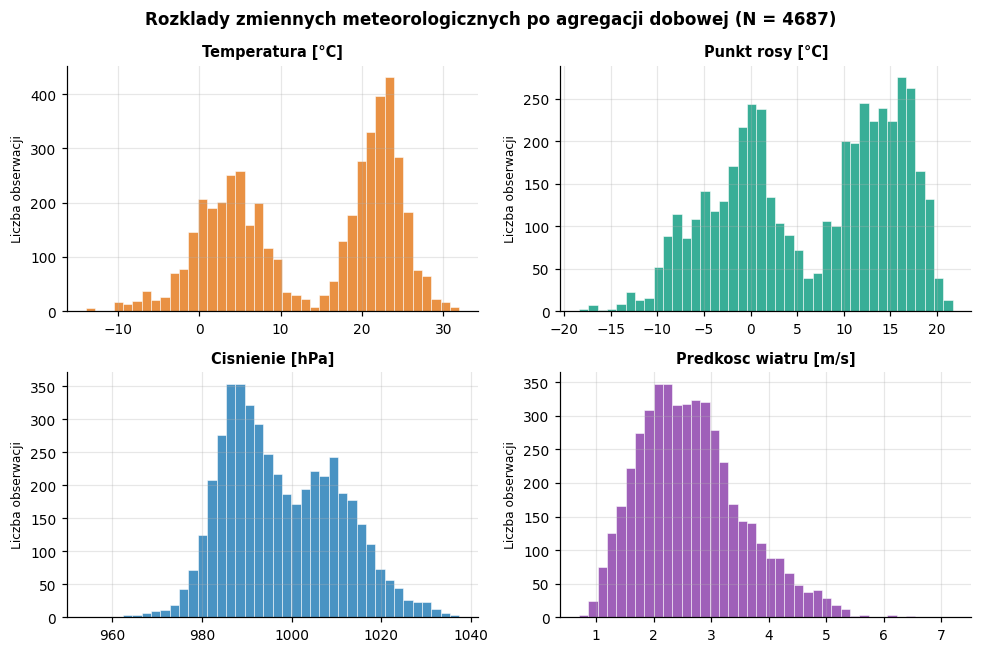

Wartosci odstajace (kryterium 1.5 x IQR):
  T   :    0  (0.0%)
  TD  :    0  (0.0%)
  P   :    2  (0.0%)
  W   :   65  (1.4%)


In [ ]:
fig, osie = plt.subplots(2, 2, figsize=(9, 6))

for os_, zm in zip(osie.flat, ZM):
    os_.hist(dane[zm], bins=40, color=KOL[zm], alpha=0.85, edgecolor='white', linewidth=0.4)
    os_.set_title(OPISY[zm], fontsize=9.5, fontweight='bold')
    os_.set_ylabel('Liczba obserwacji', fontsize=8)

fig.suptitle('Rozklady zmiennych meteorologicznych po agregacji dobowej (N = 4687)',
             fontsize=11, fontweight='bold')
fig.tight_layout()
plt.show()

print('Wartosci odstajace (kryterium 1.5 x IQR):')
for zm in ZM:
    q1, q3 = dane[zm].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((dane[zm] < q1 - 1.5*iqr) | (dane[zm] > q3 + 1.5*iqr)).sum()
    print(f'  {zm:4s}: {n:4d}  ({n/len(dane)*100:.1f}%)')

Wykres 1. — histogramy rozkładów badanych zmiennych meteorologicznych

Rozkłady dostarczają istotnej informacji interpretacyjnej. **Temperatura i punkt rosy mają wyraźny rozkład dwumodalny** — widoczne są dwa oddzielne skupienia wartości. Nie jest to anomalia, lecz bezpośrednia konsekwencja konstrukcji zbioru: dane obejmują wyłącznie zimę i lato, więc miesiące przejściowe, które wypełniłyby środek rozkładu, po prostu nie istnieją. Ta dwumodalność jest sygnałem, że **liczenie statystyk na całym zbiorze łącznie (bez podziału na sezony) jest metodycznie niebezpieczne** — zostanie to uwzględnione w całej dalszej analizie.

Ciśnienie ma rozkład zbliżony do normalnego z lekką prawostronną asymetrią, prędkość wiatru — rozkład prawoskośny, typowy dla zmiennych nieujemnych ograniczonych z jednej strony.

Analiza metodą 1,5 × IQR wykazała niewielki udział wartości odstających (poniżej 1,5% dla każdej zmiennej, przy 0% dla temperatury i punktu rosy). Wszystkie mieszczą się w granicach fizycznej logiki i reprezentują rzeczywiste zdarzenia meteorologiczne (silne wyże, epizody wietrzne), dlatego **nie zostają usunięte**.

##### Ostatnim krokiem tej części jest sprawdzenie kompletności czasowej zbioru.

In [ ]:
pokrycie = dane.pivot_table(index='Rok', columns='Mies', values='folder', aggfunc='nunique')
print('Liczba lokalizacji z danymi w kazdej komorce rok x miesiac (max 20):')
print(pokrycie.fillna(0).astype(int).to_string())

Liczba lokalizacji z danymi w kazdej komorce rok x miesiac (max 20):
Mies   1   2   3   6   7   8
Rok                         
2019   2  20  20  20  13  20
2020  12  19  20  20  20  20
2021  19  20  20  20  16  20
2022  11  20  20  20  20   0
2023   0  20  19  20  20  12
2024  12  20  20  20  20  20
2025  14  20  20  20  20  20
2026  13  20  20  20   0   0


Tabela 4. — pokrycie czasowe zbioru (liczba lokalizacji z danymi)

Tabela ujawnia trzy fakty istotne dla dalszej analizy:

1. **Obecne są wyłącznie miesiące I, II, III oraz VI, VII, VIII** — miesiące IV–V i IX–XII nie istnieją w zbiorze.
2. Cztery komórki są całkowicie puste: VIII.2022, I.2023 oraz VII i VIII.2026 (dane kończą się 30.06.2026, więc lato 2026 jest reprezentowane wyłącznie przez czerwiec). **Rok 2026 zostaje w analizie zachowany, ale konsekwentnie oznaczany jako niepełny** i wyłączony z dopasowywania trendów.
3. **Styczeń jest systematycznie ubogi w dane** (zwykle 11–19 lokalizacji zamiast 20, a w 2019 roku zaledwie 2) — jest to skutek uboczny algorytmu satelitarnego pomiaru CH4 (niski kąt Słońca i pokrywa śnieżna utrudniają odczyt), którego dane pogodowe są jedynie „pasażerem" w tym samym pliku. Braki te są zatem systematyczne, skorelowane z porą roku, a nie losowe.

---
# Część II — analiza szeregu czasowego pogody

### Analiza prowadzona jest na **średniej zbiorczej z 20 lokalizacji**, agregowanej do poziomu miesiąca tam, gdzie jest to potrzebne do oceny trendu, oraz na poziomie dobowym przy ocenie zmienności i ekstremów. Reprezentatywność uśredniania przestrzennego zostanie zweryfikowana pod koniec tej części.

## II.1 Przebieg czasowy

In [ ]:
mies = (dane.groupby(['Rok', 'Mies', 'Sezon'], as_index=False)[ZM].mean())
mies['ts'] = pd.to_datetime(dict(year=mies.Rok, month=mies.Mies, day=1))
mies = mies.sort_values('ts').reset_index(drop=True)

kalendarz = pd.date_range('2019-01-01', '2026-06-01', freq='MS')
mies_pelny = mies.set_index('ts').reindex(kalendarz)

print(f'Punktow miesiecznych z danymi: {len(mies)} '
      f'(z {len(kalendarz)} miesiecy kalendarzowych w okresie)')

Punktow miesiecznych z danymi: 44 (z 90 miesiecy kalendarzowych w okresie)


##### Analizę rozpoczynamy od wykresu przebiegu (time-series plot) każdej zmiennej. Przerwy w danych zostały celowo pozostawione jako luki w linii — połączenie punktu z marca z punktem z czerwca sugerowałoby istnienie danych w nieistniejących miesiącach wiosennych.

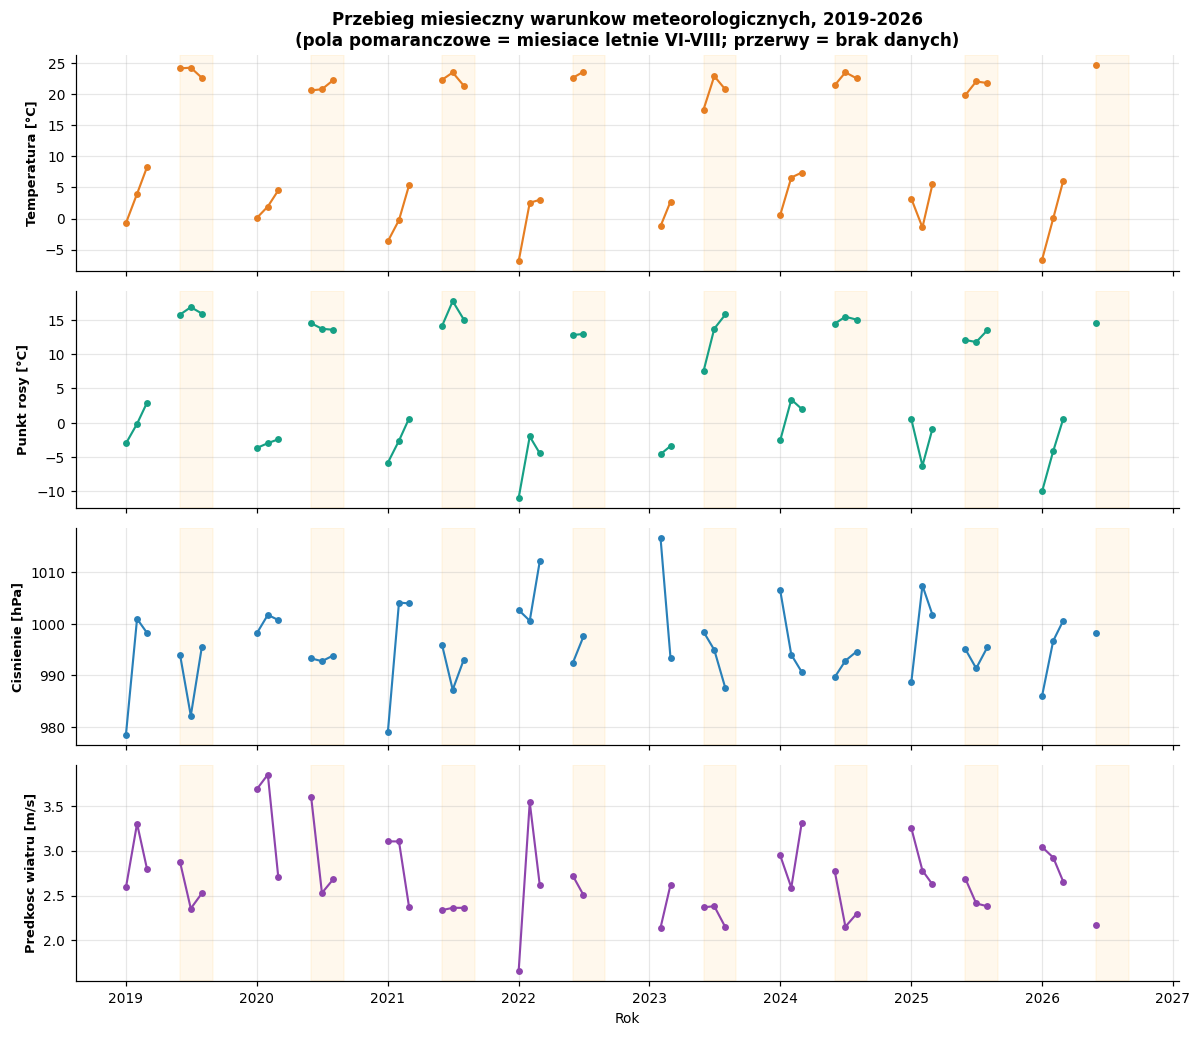

In [ ]:
fig, osie = plt.subplots(4, 1, figsize=(11, 9.5), sharex=True)

for os_, zm in zip(osie, ZM):
    os_.plot(mies_pelny.index, mies_pelny[zm], color=KOL[zm],
             lw=1.4, marker='o', ms=3.5)
    os_.set_ylabel(OPISY[zm], fontsize=8.5, fontweight='bold')
    for rok in range(2019, 2027):
        os_.axvspan(pd.Timestamp(f'{rok}-06-01'), pd.Timestamp(f'{rok}-08-31'),
                    color='orange', alpha=0.07)

osie[0].set_title('Przebieg miesieczny warunkow meteorologicznych, 2019-2026\n'
                  '(pola pomaranczowe = miesiace letnie VI-VIII; przerwy = brak danych)',
                  fontsize=11, fontweight='bold')
osie[-1].set_xlabel('Rok')
fig.tight_layout()
plt.show()

Wykres 2. — przebieg miesięczny badanych zmiennych meteorologicznych w okresie 2019–2026

Wszystkie cztery zmienne wykazują bardzo regularny przebieg o charakterze piły, odpowiadający naprzemiennym oknom zimowym i letnim — jest to spodziewana, silna sezonowość. Istotne jest jednak to, że **amplituda i poziom tych wahań nie wykazują wizualnie systematycznej zmiany w czasie**: kolejne zimy nie są konsekwentnie cieplejsze lub zimniejsze od poprzednich, ani kolejne lata gorętsze — w przeciwieństwie do zjawisk, w których szereg wyraźnie „dryfuje" w jedną stronę. Ciśnienie i wiatr wykazują większą nieregularność wahań międzysezonowych niż temperatura i punkt rosy, bez widocznej tendencji kierunkowej.

Ocena „na oko" nie jest jednak wystarczająca dla wniosku o obecności lub braku trendu — wymaga to potwierdzenia ilościowego, do czego posłuży poniższa analiza regresji.

## II.2 Trend długookresowy

##### Do ilościowej oceny trendu konieczne jest rozdzielenie podszeregów sezonowych. Wynika to z ograniczenia zbioru: przy sześciu brakujących miesiącach w roku klasyczna dekompozycja (`seasonal_decompose`, STL) dopasowałaby składową sezonową do nieistniejących danych, produkując artefakty numeryczne. Zastosowane podejście jest prostsze: dla każdego roku liczona jest osobna **średnia zimowa (I–III) i osobna średnia letnia (VI–VIII)**. W ten sposób powstają dwa równoległe podszeregi roczne, w których składowa sezonowa jest już z definicji usunięta, a trend można ocenić metodą regresji liniowej wraz z testem istotności jej współczynnika kierunkowego.

In [ ]:
sez = dane.groupby(['Rok', 'Sezon'], as_index=False)[ZM].mean()

wyniki = []
for zm in ZM:
    for s in ['ZIMA', 'LATO']:
        pod = sez[(sez.Sezon == s) & (sez.Rok <= 2025)]
        r = stats.linregress(pod.Rok, pod[zm])
        wyniki.append({
            'Zmienna': zm, 'Sezon': s,
            'Nachylenie [jedn./rok]': round(r.slope, 3),
            'p-value': f'{r.pvalue:.4f}',
            'R^2': round(r.rvalue**2, 3),
            'Istotny (p<0.05)': 'TAK' if r.pvalue < 0.05 else 'nie',
        })

pd.DataFrame(wyniki)

,Zmienna,Sezon,Nachylenie [jedn./rok],p-value,R^2,Istotny (p<0.05)
0,T,ZIMA,-0.122,0.7657,0.019,nie
1,T,LATO,-0.272,0.2484,0.254,nie
2,TD,ZIMA,-0.165,0.7320,0.026,nie
3,TD,LATO,-0.430,0.2366,0.265,nie
4,P,ZIMA,-0.159,0.8725,0.006,nie
5,P,LATO,0.160,0.5016,0.095,nie
6,W,ZIMA,-0.055,0.3169,0.198,nie
7,W,LATO,-0.051,0.1372,0.385,nie


Tabela 5. — wyniki regresji liniowej trendu dla średnich sezonowych (2019–2025)

Wynik jest jednoznaczny: **dla żadnej z czterech zmiennych meteorologicznych i w żadnym z dwóch sezonów trend nie jest statystycznie istotny**. Wartości p mieszczą się w przedziale od 0,137 (wiatr, lato) do 0,873 (ciśnienie, zima), a więc znacznie powyżej progu 0,05, przy współczynnikach determinacji R² od 0,006 do 0,385. Oznacza to, że obserwowane różnice średnich sezonowych między kolejnymi latami są nieodróżnialne od zwykłych wahań losowych.

Warto zwrócić uwagę, że nachylenia dla temperatury są ujemne w obu sezonach (−0,12 °C/rok zimą, −0,27 °C/rok latem), co przy pobieżnej lekturze mogłoby sugerować ochłodzenie. Przy p = 0,77 (zima) i p = 0,25 (lato) **nie wolno jednak wyciągać takiego wniosku** — przy zaledwie siedmiu punktach pomiarowych znak i wielkość nachylenia są w praktyce przypadkowe, a dodanie lub usunięcie jednego roku mogłoby ten znak odwrócić.

Rozstrzygnięcie to jest zresztą zgodne z wiedzą dziedzinową: **siedem lat to okres zdecydowanie zbyt krótki na wykrycie trendu klimatycznego**. Naturalna zmienność międzyroczna cyrkulacji atmosferycznej w strefie umiarkowanej (m.in. wpływ oscylacji północnoatlantyckiej, NAO) jest na tyle duża, że w pełni maskuje ewentualny słaby sygnał kierunkowy. Analizy klimatologiczne standardowo wykorzystują serie co najmniej 30-letnie.

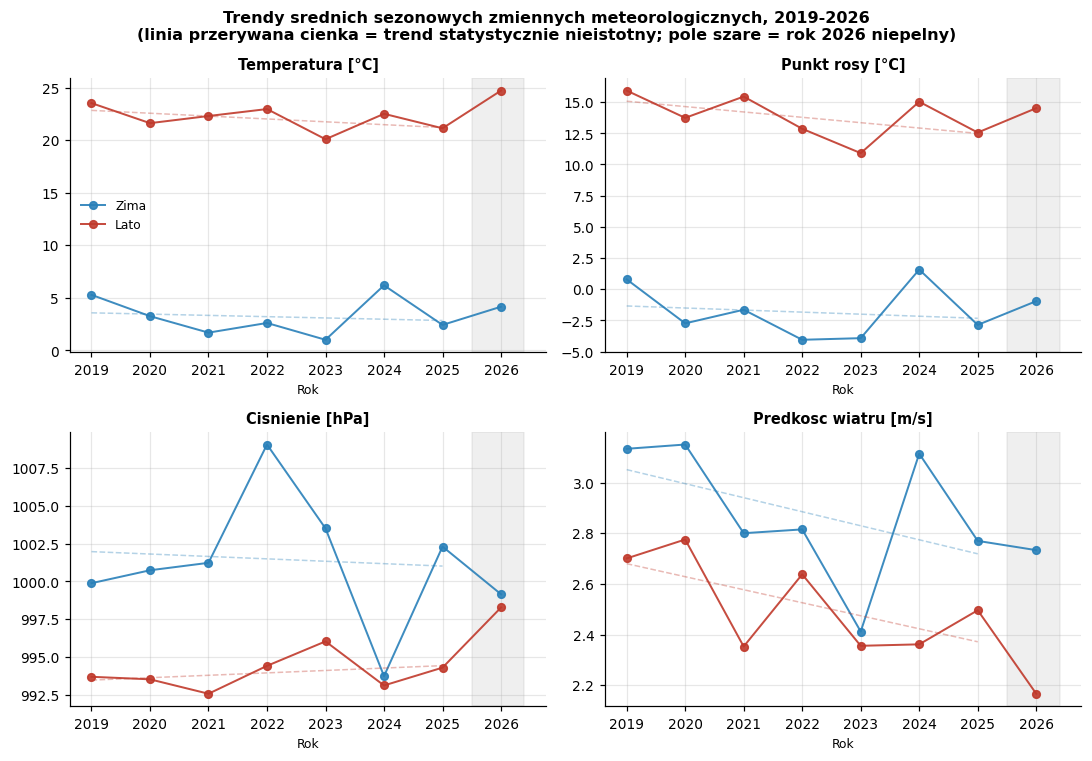

In [ ]:
fig, osie = plt.subplots(2, 2, figsize=(10, 7))

for os_, zm in zip(osie.flat, ZM):
    for s in ['ZIMA', 'LATO']:
        pod = sez[sez.Sezon == s].sort_values('Rok')
        pelne = pod[pod.Rok <= 2025]
        os_.plot(pod.Rok, pod[zm], 'o-', color=KOL_SEZ[s], lw=1.3, ms=5,
                 label=s.capitalize(), alpha=0.9)
        r = stats.linregress(pelne.Rok, pelne[zm])
        lata = np.array([2019, 2025])
        istotny = r.pvalue < 0.05
        os_.plot(lata, r.intercept + r.slope * lata, '--',
                 color=KOL_SEZ[s], lw=2 if istotny else 1,
                 alpha=0.9 if istotny else 0.35)
    os_.axvspan(2025.5, 2026.4, color='gray', alpha=0.12)
    os_.set_title(OPISY[zm], fontsize=9.5, fontweight='bold')
    os_.set_xlabel('Rok', fontsize=8)

osie.flat[0].legend(fontsize=8, frameon=False)
fig.suptitle('Trendy srednich sezonowych zmiennych meteorologicznych, 2019-2026\n'
             '(linia przerywana cienka = trend statystycznie nieistotny; pole szare = rok 2026 niepelny)',
             fontsize=10.5, fontweight='bold')
fig.tight_layout()
plt.show()

Wykres 3. — porównanie trendów średnich sezonowych z dopasowanymi prostymi regresji

Na wykresie wszystkie cztery linie trendu są narysowane cienko (co w przyjętej konwencji oznacza brak istotności) i widocznie prawie poziome — dobrze obrazuje to wniosek liczbowy z Tabeli 5. Punkty pomiarowe każdego sezonu układają się bez czytelnego porządku rosnącego ani malejącego, lecz oscylują wokół zmiennego poziomu z roku na rok. Rok 2026 (pole szare) jest zaznaczony osobno — dla lata opiera się on wyłącznie na czerwcu, dlatego widoczne na wykresie temperatury wybicie w górę tego punktu nie powinno być odczytywane jako cecha całego sezonu letniego 2026, a jedynie jako właściwość samego czerwca.

## II.3 Sezonowość

##### Skoro wykazano brak trendu, można przystąpić do analizy sezonowości bez ryzyka jej zniekształcenia przez systematyczny dryf w czasie. Poniżej przedstawiono profil miesięczny każdej zmiennej — średnią wartość dla każdego z sześciu obecnych w zbiorze miesięcy, uśrednioną po wszystkich latach.

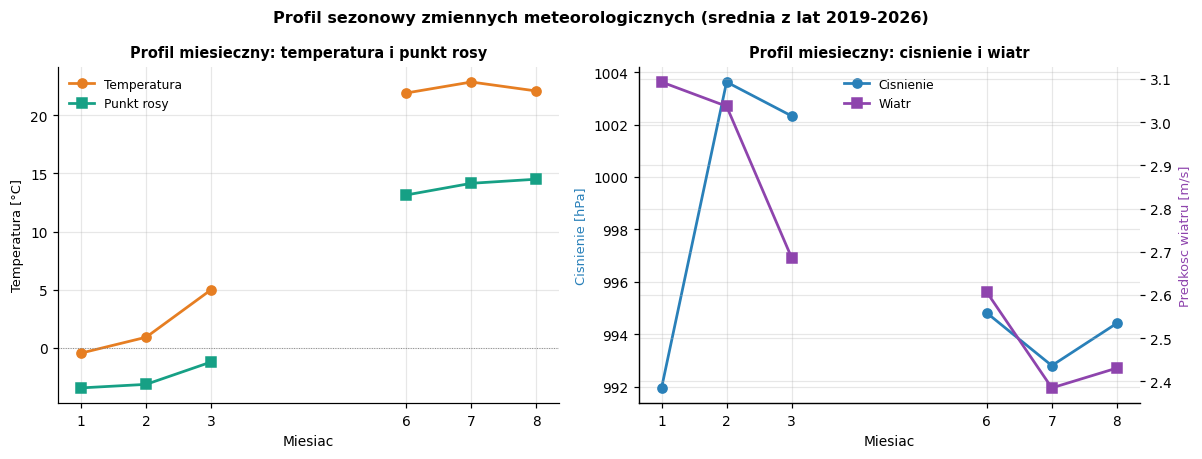

          T     TD        P     W
Mies                             
1     -0.43  -3.42   991.95  3.09
2      0.93  -3.12  1003.63  3.04
3      5.01  -1.19  1002.33  2.69
6     21.91  13.15   994.81  2.61
7     22.85  14.15   992.80  2.39
8     22.08  14.51   994.42  2.43


In [ ]:
profil = dane.groupby('Mies')[ZM].mean()

fig, osie = plt.subplots(1, 2, figsize=(11, 4.2))

a1 = osie[0]
for miesiace, etyk in [([1, 2, 3], True), ([6, 7, 8], False)]:
    pod = profil.loc[miesiace]
    a1.plot(pod.index, pod['T'], 'o-', color=KOL['T'], lw=1.8, ms=6,
            label='Temperatura' if etyk else None)
    a1.plot(pod.index, pod['TD'], 's-', color=KOL['TD'], lw=1.8, ms=6,
            label='Punkt rosy' if etyk else None)
a1.axhline(0, color='gray', lw=0.6, ls=':')
a1.set_xticks(profil.index)
a1.set_xlabel('Miesiac')
a1.set_ylabel('Temperatura [°C]', fontsize=8.5)
a1.set_title('Profil miesieczny: temperatura i punkt rosy', fontsize=9.5, fontweight='bold')
a1.legend(fontsize=8, frameon=False)

a2 = osie[1]
a2b = a2.twinx()
l1_all, l2_all = [], []
for miesiace, etyk in [([1, 2, 3], True), ([6, 7, 8], False)]:
    pod = profil.loc[miesiace]
    l1_all += a2.plot(pod.index, pod['P'], 'o-', color=KOL['P'], lw=1.8, ms=6,
                       label='Cisnienie' if etyk else None)
    l2_all += a2b.plot(pod.index, pod['W'], 's-', color=KOL['W'], lw=1.8, ms=6,
                        label='Wiatr' if etyk else None)
l1, l2 = l1_all[:1], l2_all[:1]
a2.set_xticks(profil.index)
a2.set_xlabel('Miesiac')
a2.set_ylabel('Cisnienie [hPa]', fontsize=8.5, color=KOL['P'])
a2b.set_ylabel('Predkosc wiatru [m/s]', fontsize=8.5, color=KOL['W'])
a2.set_title('Profil miesieczny: cisnienie i wiatr', fontsize=9.5, fontweight='bold')
lns = l1 + l2
a2.legend(lns, [x.get_label() for x in lns], fontsize=8, frameon=False, loc='upper center')

fig.suptitle('Profil sezonowy zmiennych meteorologicznych (srednia z lat 2019-2026)',
             fontsize=10.5, fontweight='bold')
fig.tight_layout()
plt.show()

print(profil.round(2).to_string())

Wykres 4. — profil miesięczny zmiennych meteorologicznych

Profil temperatury i punktu rosy pokazuje oczekiwany, silny kontrast sezonowy: średnia temperatura rośnie od ok. −0,4 °C w styczniu do ok. 23 °C w lipcu, a punkt rosy — od ok. −3,4 °C do ok. 14,5 °C. Charakterystyczne jest, że obie krzywe są niemal równoległe w części zimowej, natomiast latem rozstęp między nimi (deficyt punktu rosy, czyli pośrednio wilgotność względna) jest większy — jest to zgodne z fizyką: powietrze cieplejsze ma większą zdolność do przenoszenia pary wodnej bez kondensacji, więc przy tej samej wilgotności bezwzględnej punkt rosy „odstaje" od temperatury bardziej latem niż zimą.

Ciśnienie ma najmniej regularny profil sezonowy spośród badanych zmiennych — waha się w wąskim przedziale 992–1004 hPa bez wyraźnego wzorca miesięcznego, co jest zgodne z jego naturą: ciśnienie jest kształtowane głównie przez przemieszczające się układy baryczne (niże i wyże), a nie przez cykl słoneczny. Prędkość wiatru jest nieznacznie wyższa zimą (ok. 3,0–3,1 m/s w styczniu–lutym) niż latem (ok. 2,4–2,6 m/s) — zgodnie z typowym dla Polski silniejszym wymuszeniem cyrkulacyjnym w chłodnej porze roku (częstsze i głębsze niże znad Atlantyku).

##### Sam profil uśredniony po wszystkich latach nie pokazuje jednak, czy sezonowość jest **stabilna** w czasie, czy też jej przebieg zmienia się między wcześniejszymi a późniejszymi latami badanego okresu. W tym celu zbiór lat podzielono na cztery dwuletnie interwały (2019–2020, 2021–2022, 2023–2024, 2025–2026) i naniesiono profile miesięczne temperatury i punktu rosy każdego interwału na wspólny wykres.

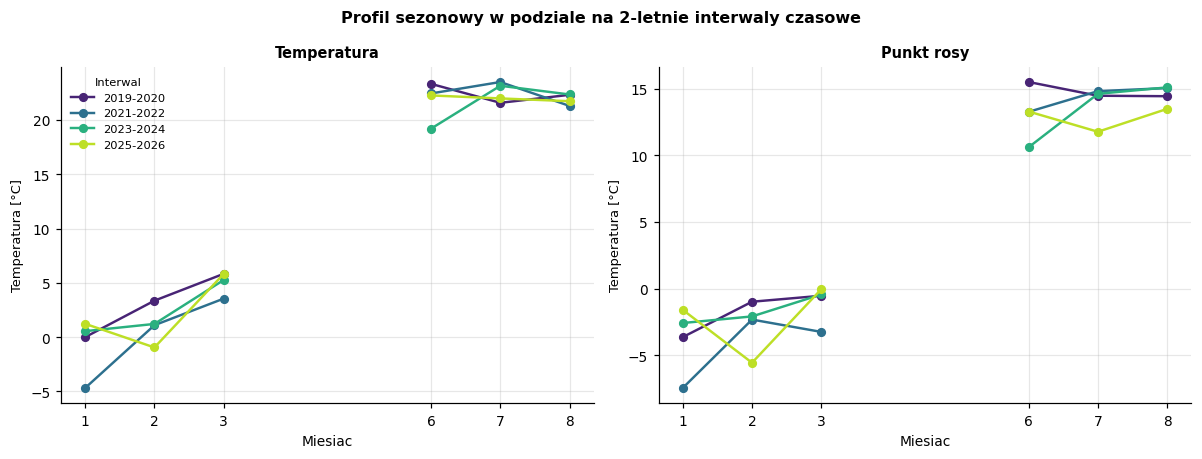

In [ ]:
dane['interwal'] = pd.cut(dane.Rok, bins=[2018, 2020, 2022, 2024, 2026],
                          labels=['2019-2020', '2021-2022', '2023-2024', '2025-2026'])
prof_int = dane.groupby(['interwal', 'Mies'], observed=True)[['T', 'TD']].mean()

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
kolory_int = plt.cm.viridis(np.linspace(0.1, 0.9, 4))

for (interwal, kolor) in zip(prof_int.index.get_level_values(0).unique(), kolory_int):
    pod = prof_int.loc[interwal]
    for miesiace, etyk in [([1, 2, 3], True), ([6, 7, 8], False)]:
        cz = pod.loc[pod.index.isin(miesiace)]
        a1.plot(cz.index, cz['T'], 'o-', color=kolor, lw=1.6, ms=5,
                label=interwal if etyk else None)
        a2.plot(cz.index, cz['TD'], 'o-', color=kolor, lw=1.6, ms=5,
                label=interwal if etyk else None)

for os_, tyt in [(a1, 'Temperatura'), (a2, 'Punkt rosy')]:
    os_.set_xticks([1, 2, 3, 6, 7, 8])
    os_.set_xlabel('Miesiac')
    os_.set_ylabel('Temperatura [°C]', fontsize=8.5)
    os_.set_title(tyt, fontsize=9.5, fontweight='bold')

a1.legend(fontsize=7.5, frameon=False, title='Interwal', title_fontsize=7.5)
fig.suptitle('Profil sezonowy w podziale na 2-letnie interwaly czasowe',
             fontsize=10.5, fontweight='bold')
fig.tight_layout()
plt.show()

Wykres 5. — sezonowość temperatury i punktu rosy w podziale na czteroletnie interwały czasowe

Krzywe czterech interwałów w dużym stopniu **pokrywają się ze sobą**, co jest wizualnym potwierdzeniem wniosku z regresji trendu: sezonowy „kształt" roku (niska temperatura zimą, wysoka latem) jest zjawiskiem stabilnym w badanym okresie i nie ulega systematycznemu przesunięciu ani deformacji. Widoczne są jednak lokalne odchylenia poszczególnych interwałów w konkretnych miesiącach — np. luty interwału 2025–2026 wypada wyraźnie chłodniej niż luty pozostałych interwałów, a marzec jest za to zbliżony we wszystkich okresach. Tego rodzaju odchylenia mieszczą się jednak w zakresie zwykłej zmienności międzyrocznej, a nie tworzą spójnego wzorca przesuwającego się w jedną stronę na przestrzeni całego okresu — co jest kolejnym potwierdzeniem braku trendu.

## II.4 Ocena okresów ekstremalnych

##### Ostatnim elementem analizy szeregu czasowego jest zbadanie częstości występowania wartości ekstremalnych w poszczególnych latach. Dzień ekstremalny zdefiniowano jako dobę, w której wartość danej zmiennej przekracza 95. percentyl (dla ciepła, wilgoci, ciśnienia i wiatru) lub jest niższa od 5. percentyla (dla chłodu i suszy powietrza) wyznaczony dla całego badanego okresu 2019–2026. Ponieważ zbiór zawiera zarówno zimę, jak i lato, sensowne jest rozróżnienie ekstremów „ciepłych" i „zimnych" dla temperatury i punktu rosy — w przeciwnym razie próg 95. percentyla wykrywałby niemal wyłącznie dni letnie, a próg 5. percentyla niemal wyłącznie dni zimowe, co nie dawałoby żadnej nowej informacji ponad znany już podział sezonowy.

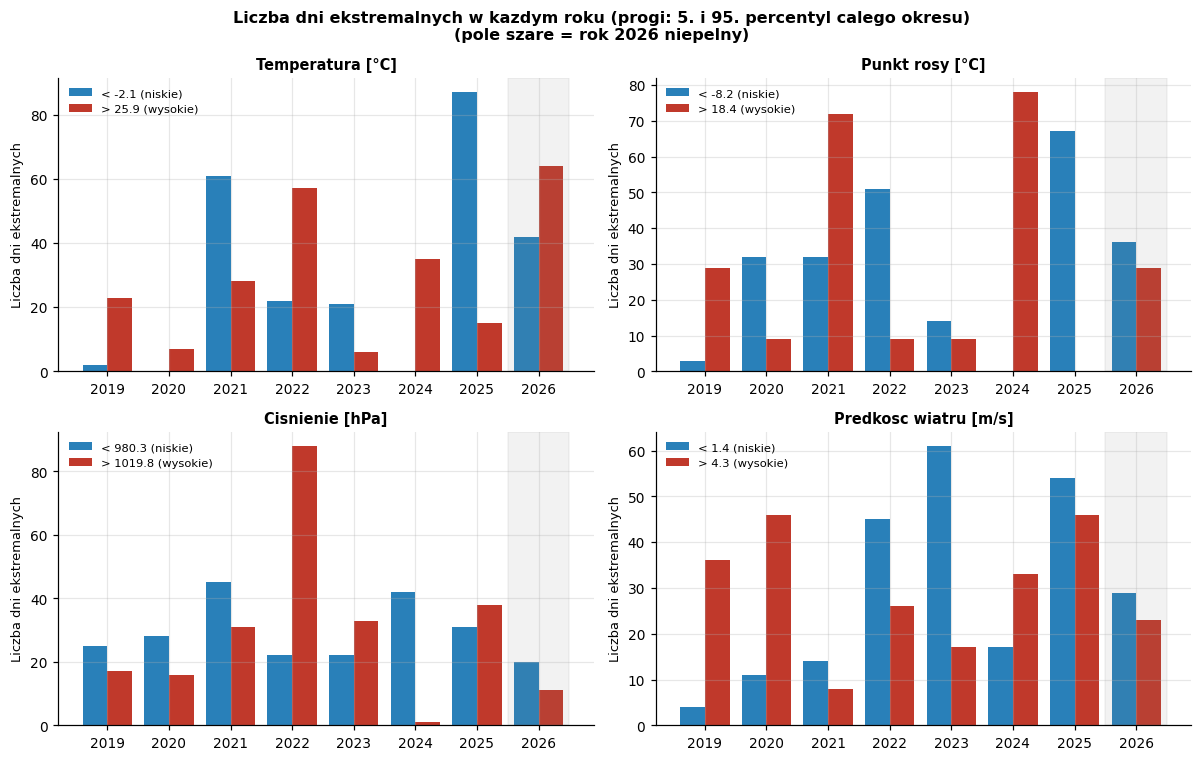

In [ ]:
progi = {}
for zm in ZM:
    progi[zm] = (dane[zm].quantile(0.05), dane[zm].quantile(0.95))

fig, osie = plt.subplots(2, 2, figsize=(11, 7))

for os_, zm in zip(osie.flat, ZM):
    p5, p95 = progi[zm]
    hi = dane.groupby('Rok').apply(lambda g: (g[zm] > p95).sum(), include_groups=False)
    lo = dane.groupby('Rok').apply(lambda g: (g[zm] < p5).sum(), include_groups=False)
    x = np.arange(len(hi))
    os_.bar(x - 0.2, lo.values, width=0.4, color='#2980b9', label=f'< {p5:.1f} (niskie)')
    os_.bar(x + 0.2, hi.values, width=0.4, color='#c0392b', label=f'> {p95:.1f} (wysokie)')
    os_.set_xticks(x); os_.set_xticklabels(hi.index)
    os_.set_ylabel('Liczba dni ekstremalnych', fontsize=8.5)
    os_.set_title(OPISY[zm], fontsize=9.5, fontweight='bold')
    os_.legend(fontsize=7.5, frameon=False)
    os_.axvspan(x[-1] - 0.5, x[-1] + 0.5, color='gray', alpha=0.10)

fig.suptitle('Liczba dni ekstremalnych w kazdym roku (progi: 5. i 95. percentyl calego okresu)\n'
             '(pole szare = rok 2026 niepelny)', fontsize=10.5, fontweight='bold')
fig.tight_layout()
plt.show()

Wykres 6. — liczba dni ekstremalnych w każdym roku dla każdej zmiennej meteorologicznej

Rozkład ekstremów w czasie jest wyraźnie **nieregularny, bez czytelnej tendencji narastającej ani malejącej** — co jest zgodne z wcześniej wykazanym brakiem trendu. Warto jednak odnotować kilka konkretnych obserwacji, przydatnych do scharakteryzowania poszczególnych lat badanego okresu:

- **2021 i 2025** wyróżniają się dużą liczbą dni z niską temperaturą (odpowiednio 61 i 87 dni poniżej 5. percentyla) — sugeruje to, że w tych latach w obrębie próbkowanych okien styczeń–marzec występowały wyraźnie chłodniejsze epizody niż przeciętnie.
- **2022** ma rekordową liczbę dni z wysokim ciśnieniem (88 dni powyżej 95. percentyla) przy jednoczesnym relatywnie niewielkim rozrzucie temperatury — obraz zgodny z częstym w tym roku utrzymywaniem się rozbudowanych układów wyżowych.
- **2023 i 2025** mają najwięcej dni z niską prędkością wiatru (61 i 54 dni poniżej 5. percentyla), co może wskazywać na częstsze okresy stagnacji mas powietrza w tych latach.
- Żaden rok nie dominuje jednocześnie w więcej niż jednej lub dwóch kategoriach ekstremów, co przeczy hipotezie o istnieniu roku systematycznie „ekstremalnego" pod każdym względem — w przeciwieństwie do sytuacji, jaką dałoby się zaobserwować przy istnieniu silnego, jednokierunkowego trendu klimatycznego.

Należy przy tym pamiętać o zastrzeżeniu ze wstępu: styczeń ma systematycznie mniej obserwacji niż pozostałe miesiące, a rok 2026 jest niepełny (zaznaczony szarym polem) — oba te fakty mogą częściowo wpływać na liczbę wykrytych ekstremów w tych okresach.

## II.5 Zależności między zmiennymi meteorologicznymi

##### Ostatnim krokiem analizy jest zbadanie zależności fizycznych łączących cztery badane zmienne. Ponieważ każda z nich ma silny cykl roczny, korelacja policzona na danych surowych mierzyłaby przede wszystkim wspólny cykl sezonowy, a nie rzeczywisty związek fizyczny (klasyczny przypadek korelacji pozornej — np. temperatura i punkt rosy są oba niskie zimą i wysokie latem niezależnie od tego, czy istnieje między nimi bezpośredni związek przyczynowy). Poprawnym postępowaniem jest policzenie korelacji na **anomaliach**, tzn. odchyleniach każdej obserwacji od średniej dla danego miesiąca kalendarzowego — w ten sposób usuwa się wspólny cykl, a pozostała korelacja opisuje wyłącznie równoczesne odchylenia od typowego stanu dla danej pory roku.

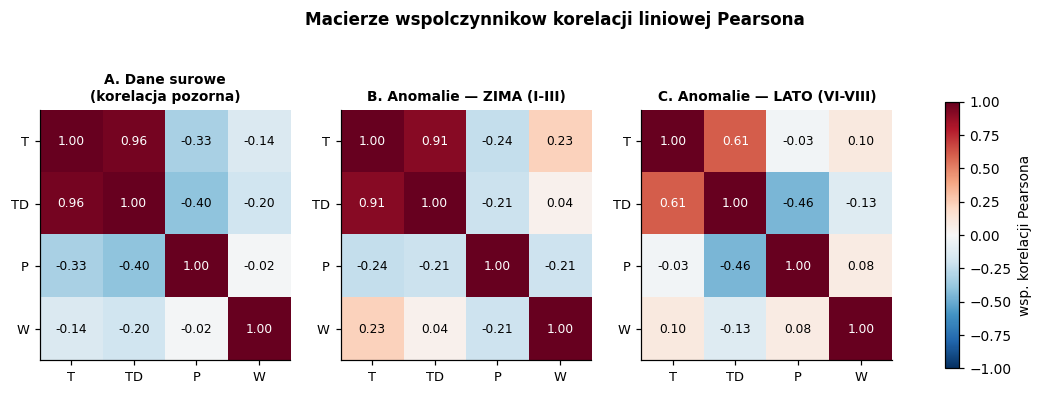

In [ ]:
for zm in ZM:
    dane[zm + '_an'] = dane[zm] - dane.groupby('Mies')[zm].transform('mean')

ANOM = ['T_an', 'TD_an', 'P_an', 'W_an']
etykiety = ['T', 'TD', 'P', 'W']

macierze = {
    'A. Dane surowe\n(korelacja pozorna)': dane[ZM].corr(),
    'B. Anomalie — ZIMA (I-III)': dane[dane.Sezon == 'ZIMA'][ANOM].corr(),
    'C. Anomalie — LATO (VI-VIII)': dane[dane.Sezon == 'LATO'][ANOM].corr(),
}

fig, osie = plt.subplots(1, 3, figsize=(12.5, 4.2))
for os_, (tytul, mac) in zip(osie, macierze.items()):
    im = os_.imshow(mac.values, cmap='RdBu_r', vmin=-1, vmax=1)
    os_.set_xticks(range(4)); os_.set_xticklabels(etykiety, fontsize=8.5)
    os_.set_yticks(range(4)); os_.set_yticklabels(etykiety, fontsize=8.5)
    os_.set_title(tytul, fontsize=9, fontweight='bold')
    os_.grid(False)
    for i in range(4):
        for j in range(4):
            v = mac.values[i, j]
            os_.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=8,
                     color='white' if abs(v) > 0.6 else 'black')

fig.colorbar(im, ax=osie, shrink=0.75, label='wsp. korelacji Pearsona')
fig.suptitle('Macierze wspolczynnikow korelacji liniowej Pearsona', fontsize=11, fontweight='bold')
plt.show()

Wykres 7. — macierze współczynników korelacji liniowej Pearsona: dane surowe oraz anomalie w podziale na sezony

Porównanie macierzy A z macierzami B i C dobrze pokazuje skalę zniekształcenia wprowadzanego przez wspólny cykl sezonowy. W macierzy **A** korelacja między temperaturą a punktem rosy wynosi aż **0,96** — wartość ta jest jednak w dużej mierze artefaktem: oba szeregi są niskie zimą i wysokie latem niezależnie od siły ich rzeczywistego związku fizycznego. Po usunięciu cyklu (macierze B i C) współczynnik ten spada do **0,91 zimą** i **0,61 latem** — i dopiero te wartości opisują faktyczną zależność fizyczną (cieplejsze powietrze potrafi utrzymać więcej pary wodnej bez kondensacji, stąd dodatnia korelacja utrzymuje się, choć jest wyraźnie słabsza niż sugerowałaby analiza naiwna).

Zwraca uwagę wyraźna **różnica siły tej zależności między sezonami** (0,91 vs. 0,61). Zimą masy powietrza są zazwyczaj bardziej jednorodne termicznie i wilgotnościowo w skali regionu (dominacja dużych układów barycznych), więc temperatura i wilgotność „poruszają się razem" niemal w lockstepie. Latem, przy silnej konwekcji termicznej i lokalnym parowaniu z gleby czy roślinności, wilgotność bywa modulowana niezależnie od samej temperatury powietrza (np. dzień może być gorący, ale suchy po okresie bezdeszczowym, albo umiarkowanie ciepły, lecz parny po opadach) — stąd słabszy związek.

Druga istotna zależność to korelacja punktu rosy z ciśnieniem, wyraźnie silniejsza **latem (−0,46)** niż zimą (−0,21). Ujemny znak jest fizycznie sensowny: wysokie ciśnienie odpowiada zwykle warunkom wyżowym — osiadaniu suchego powietrza i rozpraszaniu chmur, co obniża wilgotność przy gruncie, natomiast niskie ciśnienie wiąże się z napływem wilgotnych mas powietrza znad oceanu i opadami. Silniejszy związek latem sugeruje, że to właśnie w tej porze roku różnice w typie masy powietrza (morska/kontynentalna, wyżowa/niżowa) przekładają się najsilniej na odczuwaną wilgotność.

Korelacja wiatru z pozostałymi zmiennymi jest we wszystkich trzech macierzach **słaba** (wartości bezwzględne poniżej 0,24), z niewielkim wzmocnieniem zimą względem ciśnienia (−0,21) — zgodnie z tym, że to właśnie zimą przemieszczające się głębokie niże znad Atlantyku generują najsilniejsze epizody wietrzne, wiążące się jednocześnie ze spadkiem ciśnienia.

## II.6 Zmienność przestrzenna między lokalizacjami

##### Dla pełności obrazu warto krótko zweryfikować, w jakim stopniu przyjęte na początku tej części uśrednianie dwudziestu lokalizacji w jedną serię zbiorczą jest uzasadnione — tzn. czy różnice pogody między lokalizacjami nie są na tyle duże, by zacierać obraz przy uśrednianiu.

In [ ]:
wariancja_calk = dane[ZM].var()
print('Udzial wariancji kazdej zmiennej wyjasniany przez lokalizacje (rozrzut przestrzenny):')
for zm in ZM:
    udzial = dane.groupby('folder')[zm].transform('mean').var() / wariancja_calk[zm]
    rozstep = dane.groupby('folder')[zm].mean().max() - dane.groupby('folder')[zm].mean().min()
    print(f'  {zm:3s}: {udzial*100:5.1f}%   (rozstep srednich miedzy lokalizacjami: {rozstep:.2f})')

Udzial wariancji kazdej zmiennej wyjasniany przez lokalizacje (rozrzut przestrzenny):
  T  :   0.2%   (rozstep srednich miedzy lokalizacjami: 1.97)
  TD :   1.3%   (rozstep srednich miedzy lokalizacjami: 2.80)
  P  :  64.2%   (rozstep srednich miedzy lokalizacjami: 29.90)
  W  :   4.1%   (rozstep srednich miedzy lokalizacjami: 0.82)


Wynik jest zaskakujący i wart osobnego komentarza, ponieważ **dzieli cztery zmienne na dwie wyraźnie różne grupy**, a nie potwierdza jednej wspólnej tezy.

Dla **temperatury (0,2%) i punktu rosy (1,3%)** udział wariancji przestrzennej jest rzeczywiście znikomy — jest to wynik fizycznie oczekiwany, ponieważ badane lokalizacje leżą w zbliżonej szerokości geograficznej i strefie klimatycznej, a warunki termiczne w skali dobowej są kształtowane głównie przez wielkoskalowe masy powietrza, jednakowe dla całego regionu.

Dla **ciśnienia wynik jest zupełnie inny — lokalizacja wyjaśnia aż 64,2% wariancji**, przy rozstępie średnich między lokalizacjami sięgającym niemal 30 hPa. Nie jest to błąd ani niespójność z poprzednimi wnioskami, lecz efekt dobrze znanej zależności ciśnienia od **wysokości nad poziomem morza** — nawet stosunkowo niewielkie różnice wysokości (rzędu kilkudziesięciu-kilkuset metrów) między lokalizacjami przekładają się na stałe przesunięcie w wartości ciśnienia na poziomie stacji, niezależne od bieżącej sytuacji barycznej. Dla wiatru udział lokalizacji (4,1%) jest niewielki, ale już zauważalny — sensownie tłumaczy to zróżnicowana ekspozycja terenu (otwarte tereny rolnicze vs. obszary o bardziej urozmaiconej rzeźbie).

Wniosek dla całej analizy jest taki, że uśrednianie przestrzenne w Częściach II.1–II.5 było **w pełni uzasadnione dla temperatury i punktu rosy** — to właśnie te dwie zmienne stanowiły główny przedmiot analizy sezonowości i trendu. Dla ciśnienia różnice między lokalizacjami są realne i wynikają z ich topografii, jednak nie zaburzają one wniosków o **zmienności czasowej** (trend, sezonowość), ponieważ ten efekt wysokościowy jest w przybliżeniu stały w czasie dla danej lokalizacji — odejmuje się on w praktyce przy porównywaniu tej samej lokalizacji między latami czy miesiącami, a ujawnia wyłącznie przy uśrednianiu przekrojowym, jak w tym akapicie.

---
# Wnioski końcowe

Przeprowadzona analiza szeregów czasowych warunków meteorologicznych (temperatura, punkt rosy, ciśnienie, prędkość wiatru) w otoczeniu badanych obiektów w okresie 2019–2026 pozwala na sformułowanie następujących wniosków.

**1. W żadnej z czterech zmiennych meteorologicznych nie stwierdzono statystycznie istotnego trendu długookresowego.** Regresja liniowa średnich sezonowych dała wartości p w przedziale 0,137–0,873 dla wszystkich kombinacji zmiennej i sezonu, a więc znacznie powyżej progu istotności 0,05, przy współczynnikach determinacji R² nieprzekraczających 0,39. Obserwowane różnice między latami są nieodróżnialne od naturalnych wahań losowych. Wynik ten jest **oczekiwany, a nie negatywny** — siedmioletnia seria jest zbyt krótka, by wykryć w niej sygnał klimatyczny na tle silnej naturalnej zmienności międzyrocznej cyrkulacji atmosferycznej w strefie umiarkowanej; standardowe analizy klimatologiczne wymagają serii co najmniej 30-letnich.

**2. Wszystkie badane zmienne wykazują silną, regularną sezonowość, stabilną w badanym okresie.** Temperatura zmienia się od ok. −0,4 °C w styczniu do ok. 23 °C w lipcu, punkt rosy od ok. −3,4 °C do ok. 14,5 °C. Porównanie profili sezonowych w czterech dwuletnich interwałach czasowych (2019–2020 … 2025–2026) wykazało, że przebieg roczny **nie ulega systematycznemu przesunięciu ani deformacji** — krzywe poszczególnych interwałów w dużej mierze się pokrywają, z jedynie lokalnymi, niesystematycznymi odchyleniami w pojedynczych miesiącach.

**3. Rozkład dni ekstremalnych w czasie jest nieregularny i nie tworzy spójnego wzorca.** Analiza progów 5. i 95. percentyla wykazała, że poszczególne lata wyróżniają się różnymi typami ekstremów — 2021 i 2025 dużą liczbą chłodnych dni, 2022 rekordową liczbą dni z wysokim ciśnieniem, 2023 i 2025 dużą liczbą dni bezwietrznych — lecz żaden rok nie jest ekstremalny jednocześnie pod wieloma względami, co dodatkowo potwierdza brak jednokierunkowego trendu.

**4. Zależności między zmiennymi meteorologicznymi są fizycznie spójne i sezonowo zmienne co do siły.** Korelacja temperatury z punktem rosy (po usunięciu wspólnego cyklu rocznego) wynosi 0,91 zimą i 0,61 latem — silniejsza zimą ze względu na większą jednorodność termiczno-wilgotnościową dużych mas powietrza w tej porze roku, słabsza latem wskutek niezależnej modulacji wilgotności przez konwekcję i parowanie lokalne. Korelacja punktu rosy z ciśnieniem jest wyraźnie silniejsza latem (−0,46) niż zimą (−0,21), co odzwierciedla sezonową zmianę znaczenia typu masy powietrza (wyżowa/niżowa) dla wilgotności przy gruncie. Prędkość wiatru jest słabo skorelowana z pozostałymi zmiennymi we wszystkich sezonach, z nieznacznym wzmocnieniem związku z ciśnieniem zimą — zgodnie z sezonowością głębokich niży znad Atlantyku.

**5. Zmienność przestrzenna między lokalizacjami zależy od rodzaju zmiennej — pomijalna dla temperatury i wilgotności, znacząca dla ciśnienia.** Lokalizacja wyjaśnia zaledwie 0,2% wariancji temperatury i 1,3% punktu rosy, co potwierdza zasadność uśredniania dwudziestu punktów w jedną serię zbiorczą przy analizie ich trendu i sezonowości. Dla ciśnienia lokalizacja wyjaśnia natomiast aż 64,2% wariancji, co jest efektem różnic wysokości nad poziomem morza między stacjami, a nie zjawiskiem czasowym — nie podważa to jednak wniosków o braku trendu i stabilności sezonowości ciśnienia, ponieważ efekt ten jest w przybliżeniu stały dla danej lokalizacji w całym badanym okresie. Wiatr zajmuje pozycję pośrednią (4,1%), odzwierciedlającą zróżnicowaną ekspozycję terenu.

### Ograniczenia analizy

1. **Brak sześciu miesięcy w roku** (IV–V i IX–XII) uniemożliwił zastosowanie klasycznej dekompozycji szeregu czasowego oraz pełną ocenę cyklu rocznego — nie wiadomo, jak wygląda przejście jesień–zima ani wiosna–lato.
2. **Systematyczne braki w styczniu** (11–19 lokalizacji zamiast 20, a w 2019 r. tylko 2 lokalizacje), wynikające z ograniczeń pomiaru satelitarnego CH4, którego dane pogodowe są w tym zbiorze jedynie „pasażerem". Może to obniżać wiarygodność wyników dla tego konkretnego miesiąca.
3. **Niepełny rok 2026** (brak lipca i sierpnia) — zachowany na wykresach, lecz konsekwentnie wyłączany z dopasowywania trendów; wartości dla lata 2026 opierają się wyłącznie na czerwcu.
4. **Krótki horyzont czasowy (7 lat)** w zestawieniu z naturalną zmiennością pogody w strefie umiarkowanej uniemożliwia formułowanie jakichkolwiek wniosków o charakterze klimatycznym — uzyskany brak trendu należy interpretować wyłącznie jako brak trendu wykrywalnego w tej konkretnej, krótkiej serii, a nie jako dowód stabilności klimatu w dłuższej perspektywie.